In [1]:
%load_ext autoreload
%autoreload 2  # Autoreload all modules

from utils.paths import *
from utils.constants import *
from utils.analysis import *
from utils.plotting import *
from utils.rootfuncs import *
import numpy as np
import xarray as xr
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import itertools as it
from matplotlib import rcParams
from dateutil.relativedelta import relativedelta
import calendar
from matplotlib.cm import get_cmap
import warnings
from scipy.stats import linregress, pearsonr
import warnings
from scipy.optimize import minimize 
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings('ignore', category = FutureWarning)
warnings.filterwarnings('ignore', category = pd.errors.PerformanceWarning)

rcParams['font.size'] = 5.5
rcParams['axes.titlesize'] = 5.5
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

prefix = '20230512'

In [2]:
minirhizotron, ingrowth = get_observation()
annual_minirhizotron_obs, minirhizotron_2018_mean_obs, minirhizotron_2018_std_obs, ingrowth_2014_2017_mean_obs, ingrowth_2014_2017_std_obs = convert_observation(minirhizotron, ingrowth)
annual_minirhizotron_sim, minirhizotron_2018_mean_sim, minirhizotron_2018_std_sim, ingrowth_2014_2017_mean_sim, ingrowth_2014_2017_std_sim = convert_sims(prefix)

collection_ts = read_extract_sims_ts(prefix)
temperature = read_sims_tair_annual()
pheno_obs = read_leaf_sos()

/home/ywo/Git/phenology_elm/utils/rootfuncs.py:18: DtypeWarning: Columns (5,6,7,8,9,15,16,19,20,23,24,32,33,39,40,41,49,54,59,467,504,539,546,570,636,757,758,820,846,849,852,858,859,860,861,862,863,864,866,872,875,877,880,889,906,911,935,990,1000,1037) have mixed types. Specify dtype option on import or set low_memory=False.
  cconc = pd.read_csv(os.path.join(path_input, 'FRED3_cleaned.csv'))


In [3]:
annual_minirhizotron_obs

variable     m_g_d                                                            \
pft          shrub                                                             
plot            4         6         7          8          10   11         13   
2018      0.000000  5.019351  8.818076  25.312051  15.248561  NaN  11.025141   
2019      0.010486       NaN  0.000000   0.363163   2.015747  0.0   0.000000   
2020           NaN       NaN  0.000000        NaN   0.071275  NaN   0.000000   

variable                           ... g_g_d                         \
pft                                ...  tree                          
plot            16        17   19  ...    6           7          8    
2018      2.019848  0.336944  0.0  ...   NaN    2.616599        NaN   
2019           NaN       NaN  NaN  ...   NaN    0.000000  31.982852   
2020      0.000000       NaN  NaN  ...   NaN  134.809004  25.698163   

variable                                                                    
pft                                                                         
plot              10  11          13         16         17  19          20  
2018       50.587752 NaN   50.616312  57.430496  20.462967 NaN  102.084129  
2019       20.014111 NaN   39.062600  64.861128        NaN NaN   24.329218  
2020      221.566103 NaN  113.594120        NaN  15.433376 NaN   36.248864  

[3 rows x 44 columns]

bias       rmse      corr    corr_p
m_g_d shrub  18.332726  22.814994  0.405181  0.061389
      tree    7.297932  32.852654  0.075425  0.751970
g_g_d shrub  12.651797  17.438813 -0.162014  0.471318
      tree  -38.364957  65.814701 -0.120291  0.613446

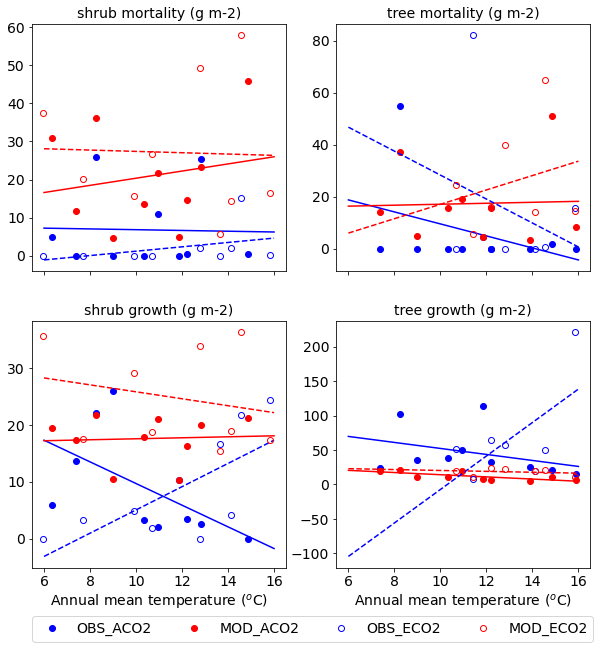

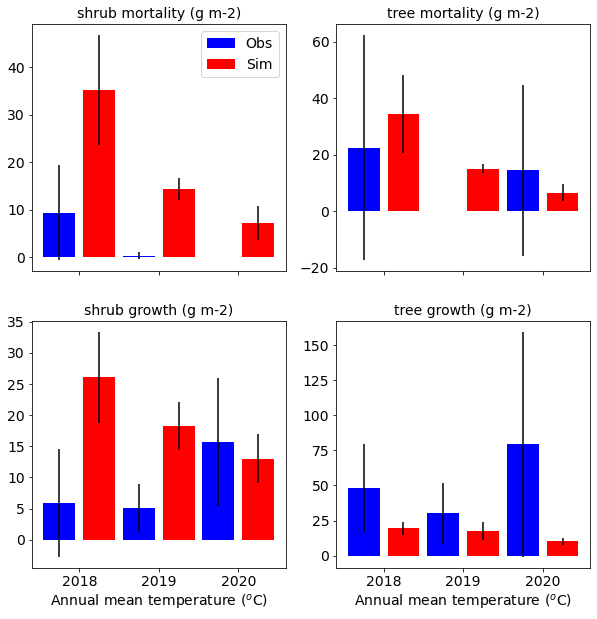

In [4]:
""" Compare the mean and sensitivity in annual values """
# plot the annual values as sensitivity plots
fig, axes = plt.subplots(2, 2, figsize = (10, 10), sharex = True)
count = 0
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    temp_obs = annual_minirhizotron_obs.loc[:, (a, b)]
    temp_sim = annual_minirhizotron_sim.loc[:, (a, b)]
    temp = temperature.loc[temp_obs.index, :]

    ax = axes.flat[count]

    for co2 in ['ACO2', 'ECO2']:
        if co2 == 'ACO2':
            chambers = chamber_list_complete[1::2] # skip ambient
            fc = ['b', 'r']
            ls = '-'
        else:
            chambers = chamber_list_complete[2::2]
            fc = ['none', 'none']
            ls = '--'
        temp_obs_temp = temp_obs.loc[:, chambers].values.reshape(-1)
        temp_sim_temp = temp_sim.loc[:, chambers].values.reshape(-1)
        temp_temp = temp.loc[:, chambers].values.reshape(-1)

        filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp) | np.isnan(temp_temp))

        ax.plot(temp_temp[filt], temp_obs_temp[filt], 'ob', markerfacecolor = fc[0], label = f'OBS_{co2}')
        res = linregress(temp_temp[filt], temp_obs_temp[filt])
        ax.plot([6, 16], [6 * res.slope + res.intercept, 16 * res.slope + res.intercept], ls = ls, color = 'b')

        ax.plot(temp_temp[filt], temp_sim_temp[filt], 'or', markerfacecolor = fc[1], label = f'MOD_{co2}')
        res = linregress(temp_temp[filt], temp_sim_temp[filt])
        ax.plot([6, 16], [6 * res.slope + res.intercept, 16 * res.slope + res.intercept], ls = ls, color = 'r')

    if a == 'm_g_d':
        title = f'{b} mortality (g m-2)'
    else:
        title = f'{b} growth (g m-2)'
    ax.set_title(title)

    if count >= 2:
        ax.set_xlabel('Annual mean temperature ($^o$C)')

    count = count + 1
ax.legend(loc = [-1.2, -0.3], ncol = 4)


# plot the annual values as bar plots
annual_minirhizotron_sim2 = annual_minirhizotron_sim.copy()
annual_minirhizotron_sim2[annual_minirhizotron_obs.isna()] = np.nan

fig, axes = plt.subplots(2, 2, figsize = (10, 10), sharex = True)
count = 0
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    ax = axes.flat[count]

    for i, y in enumerate([2018, 2019, 2020]):
        temp_obs = annual_minirhizotron_obs.loc[y, (a, b)]
        temp_sim = annual_minirhizotron_sim.loc[y, (a, b)]

        ax.bar(i * 2, temp_obs.mean(), color = 'b', label = 'Obs')
        ax.errorbar(i * 2, temp_obs.mean(), temp_obs.std(), ecolor = 'k')

        ax.bar(i * 2 + 1, temp_sim.mean(), color = 'r', label = 'Sim')
        ax.errorbar(i * 2 + 1, temp_sim.mean(), temp_sim.std(), ecolor = 'k')

        if count == 0 and i == 0:
            ax.legend()
    
    ax.set_xticks([0.5, 2.5, 4.5])
    ax.set_xticklabels(['2018', '2019', '2020'])

    if a == 'm_g_d':
        title = f'{b} mortality (g m-2)'
    else:
        title = f'{b} growth (g m-2)'
    ax.set_title(title)

    if count >= 2:
        ax.set_xlabel('Annual mean temperature ($^o$C)')

    count = count + 1


# statistic
annual_minirhizotron_errors = pd.DataFrame(np.nan, index = pd.MultiIndex.from_product([['m_g_d', 'g_g_d'], ['shrub', 'tree']]),
                                           columns = ['bias', 'rmse', 'corr', 'corr_p'])
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    temp_obs = annual_minirhizotron_obs.loc[:, (a, b)]
    temp_sim = annual_minirhizotron_sim.loc[:, (a, b)]
    temp_obs_temp = temp_obs.loc[:, chamber_list_complete].values.reshape(-1)
    temp_sim_temp = temp_sim.loc[:, chamber_list_complete].values.reshape(-1)
    filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp))
    temp_obs_temp = temp_obs_temp[filt]
    temp_sim_temp = temp_sim_temp[filt]
    annual_minirhizotron_errors.loc[(a, b), 'bias'] = np.mean(temp_sim_temp) - np.mean(temp_obs_temp)
    annual_minirhizotron_errors.loc[(a, b), 'rmse'] = np.sqrt(np.mean(np.power(temp_sim_temp - temp_obs_temp, 2)))
    rho, pval = pearsonr(temp_sim_temp, temp_obs_temp)
    annual_minirhizotron_errors.loc[(a, b), 'corr'] = rho
    annual_minirhizotron_errors.loc[(a, b), 'corr_p'] = pval
annual_minirhizotron_errors

130.03333333333333
130.03333333333333


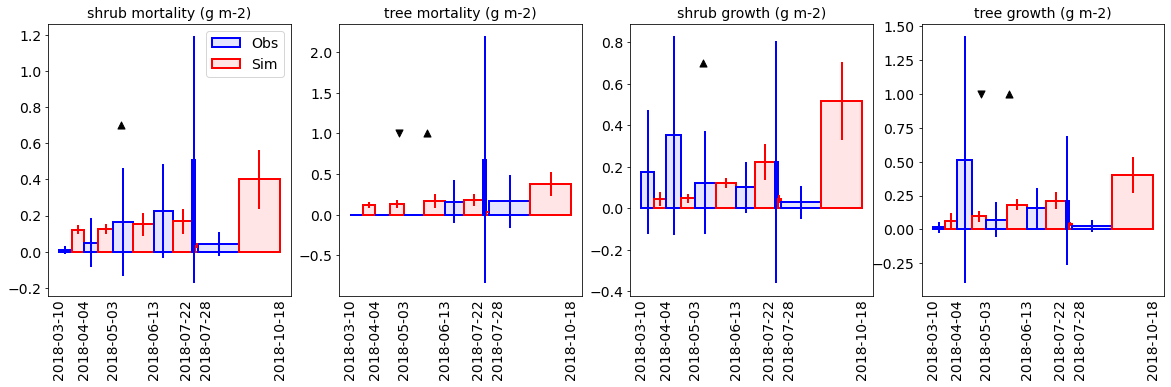

In [5]:
""" Compare the 2018 seasonal cycle """
fig, axes = plt.subplots(1, 4, figsize = (20, 5), sharex = True)
count = 0
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    temp_obs = minirhizotron_2018_mean_obs.loc[:, (a, b)]
    temp_sim = minirhizotron_2018_mean_sim.loc[:, (a, b)]
    temp_obs_std = minirhizotron_2018_std_obs.loc[:, (a, b)]
    temp_sim_std = minirhizotron_2018_std_sim.loc[:, (a, b)]

    ax = axes.flat[count]

    xticks = []
    xticklabels = []
    for j, ind in enumerate(temp_obs.index):
        width = (ind[1] - ind[0]).days
        xmin = mdates.date2num(ind[0])
        h1 = ax.bar(xmin, temp_obs.loc[ind], width = width / 2, align = 'edge', facecolor = 'b', edgecolor = 'b', lw = 2)
        h1[0].set_facecolor((0, 0, 1, 0.1))  # RGBa: blue with alpha
        h2 = ax.bar(xmin + width / 2, temp_sim.loc[ind], width = width / 2, align = 'edge', facecolor = 'r', edgecolor = 'r', lw = 2)
        h2[0].set_facecolor((1, 0, 0, 0.1))  # RGBa: red with alpha

        ax.errorbar(xmin + width / 4, temp_obs.loc[ind], yerr = temp_obs_std.loc[ind], ecolor = 'b', lw = 2)
        ax.errorbar(xmin + width * 3 / 4, temp_sim.loc[ind], yerr = temp_sim_std.loc[ind], ecolor = 'r', lw = 2)

        if j == 4:
           xticks.append(mdates.date2num(ind[0]) - width)
        elif j == 5:
           xticks.append(mdates.date2num(ind[0]) + width / 10)
        else:
           xticks.append(mdates.date2num(ind[0]))
        xticklabels.append(ind[0].strftime('%Y-%m-%d'))
    xticks.append(mdates.date2num(ind[1]))
    xticklabels.append(ind[1].strftime('%Y-%m-%d'))

    if b == 'shrub':
        doy = pheno_obs['SH'].loc[2018, :].mean()

        print(doy)

        xloc = mdates.date2num(datetime(2018, 1, 1) + relativedelta(days = doy))
        ax.scatter(xloc, 0.7, marker = '^', color = 'k', s = 50)
    else:
        doy_spruce = pheno_obs['EN'].loc[2018, :].mean()
        xloc_spruce = mdates.date2num(datetime(2018, 1, 1) + relativedelta(days = doy_spruce))
        doy_larch = pheno_obs['DN'].loc[2018, :].mean()
        xloc_larch = mdates.date2num(datetime(2018, 1, 1) + relativedelta(days = doy_larch))
        ax.scatter(xloc_spruce, 1., marker = '^', color = 'k', s = 50)
        ax.scatter(xloc_larch, 1., marker = 'v', color = 'k', s = 50)

    if count == 0:
        ax.legend([h1, h2], ['Obs', 'Sim'])

    if a == 'm_g_d':
        title = f'{b} mortality (g m-2)'
    else:
        title = f'{b} growth (g m-2)'
    ax.set_title(title)

    ax.set_xticks(xticks)
    ax.tick_params(length = 0, axis = 'x')
    ax.set_xticklabels(xticklabels, rotation = 90)

    count = count + 1

,bias,rmse,corr,corr_p
spruce,-3.159735,11.122610,-0.424235,0.221743
larch,-17.340239,25.960499,0.675864,0.031928
shrub,2.011335,5.479729,0.154908,0.669153


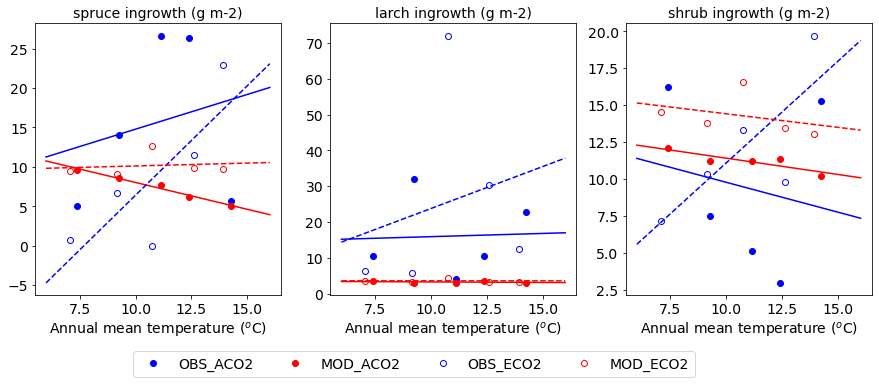

In [6]:
""" Compare the mean and sensitivity in ingrowth core annual """
# plot
fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True)
count = 0
for name in ['spruce', 'larch', 'shrub']:
    temp_obs = ingrowth_2014_2017_mean_obs.loc[name, :]
    temp_sim = ingrowth_2014_2017_mean_sim.loc[name, :]
    temp = temperature.loc[2014:2017, :].mean(axis = 0)

    ax = axes.flat[count]

    for co2 in ['ACO2', 'ECO2']:
        if co2 == 'ACO2':
            chambers = chamber_list_complete[1::2] # skip ambient
            fc = ['b', 'r']
            ls = '-'
        else:
            chambers = chamber_list_complete[2::2]
            fc = ['none', 'none']
            ls = '--'
        temp_obs_temp = temp_obs.loc[chambers].values
        temp_sim_temp = temp_sim.loc[chambers].values
        temp_temp = temp.loc[chambers].values

        filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp) | np.isnan(temp_temp))

        ax.plot(temp_temp[filt], temp_obs_temp[filt], 'ob', markerfacecolor = fc[0], label = f'OBS_{co2}')
        res = linregress(temp_temp[filt], temp_obs_temp[filt])
        ax.plot([6, 16], [6 * res.slope + res.intercept, 16 * res.slope + res.intercept], ls = ls, color = 'b')

        ax.plot(temp_temp[filt], temp_sim_temp[filt], 'or', markerfacecolor = fc[1], label = f'MOD_{co2}')
        res = linregress(temp_temp[filt], temp_sim_temp[filt])
        ax.plot([6, 16], [6 * res.slope + res.intercept, 16 * res.slope + res.intercept], ls = ls, color = 'r')

    ax.set_title(f'{name} ingrowth (g m-2)')

    ax.set_xlabel('Annual mean temperature ($^o$C)')

    count = count + 1
ax.legend(loc = [-2, -0.3], ncol = 4)


# statistic
ingrowth_2014_2017_errors = pd.DataFrame(np.nan, index = ['spruce', 'larch', 'shrub'],
                                        columns = ['bias', 'rmse', 'corr', 'corr_p'])
for name in ['spruce', 'larch', 'shrub']:
    temp_obs = ingrowth_2014_2017_mean_obs.loc[name, :]
    temp_sim = ingrowth_2014_2017_mean_sim.loc[name, :]
    temp_obs_temp = temp_obs.loc[chamber_list].values.reshape(-1)
    temp_sim_temp = temp_sim.loc[chamber_list].values.reshape(-1)
    filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp))
    temp_obs_temp = temp_obs_temp[filt]
    temp_sim_temp = temp_sim_temp[filt]
    ingrowth_2014_2017_errors.loc[name, 'bias'] = np.mean(temp_sim_temp) - np.mean(temp_obs_temp)
    ingrowth_2014_2017_errors.loc[name, 'rmse'] = np.sqrt(np.mean(np.power(temp_sim_temp - temp_obs_temp, 2)))
    rho, pval = pearsonr(temp_sim_temp, temp_obs_temp)
    ingrowth_2014_2017_errors.loc[name, 'corr'] = rho
    ingrowth_2014_2017_errors.loc[name, 'corr_p'] = pval
ingrowth_2014_2017_errors

In [7]:
""" Sanity check on whether the calculation above generated the same result as the model """

casename = 'test_US-SPR_ICB20TRCNPRDCTCBC'
params = dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35, 
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 2, 
)


growth_onset, growth_compens, mortality, _, _ = extractor(casename, params)


tvec = pd.date_range('2015-01-01 00:00:00', '2016-12-31 23:00:00', freq = '1H')
tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
growth_onset_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
growth_compens_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
mortality_sim = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))


flist = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h2.*.nc')))[:-1]
hr = xr.open_mfdataset(flist)
for pft, loc in it.product([2, 3, 11], ['hummock', 'hollow']):
    if loc == 'hummock':
        pft_id = pft
    else:
        pft_id = pft + 17
    growth_onset_sim.loc[:, (str(pft), loc)] = hr['ONSET_RATE_FROOT'][:, pft_id].values
    growth_compens_sim.loc[:, (str(pft), loc)] = hr['COMPS_RATE_FROOT'][:, pft_id].values
    mortality_sim.loc[:, (str(pft), loc)] = hr['BGLFR_FROOT'][:, pft_id].values
hr.close()


"""
var = growth_onset # mortality
var_sim = growth_onset_sim # mortality_sim
pft = 3
pft_id = 3 + 17

# filt = (var.loc[:, (str(pft), 'hummock')] > 0.7e-7) & (var.loc[:, (str(pft), 'hummock')] < 0.8e-7) & (var_sim.loc[:, (str(pft), 'hummock')] > 0.8e-7)
filt = np.abs(var.loc[:, (str(pft), 'hollow')] - var_sim.loc[:, (str(pft), 'hollow')]) > 1e-12
print(tvec[filt])

hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h1.*.nc')))[:-1])
print(hr['TSOI'][filt, 2, :].values[0, :])
print(hr['H2OSFC'][filt, :].values[0, :])
hr.close()


hr = xr.open_mfdataset(flist)
print(hr['ONSET_FLAG_ROOT'][filt, pft_id].values[0])
print(hr['ONSET_RATE_FROOT'][filt, pft_id].values[0])
ootfr = hr['ROOTFR'].values
hr.close()
hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h0.*.nc')))[:-1])
dzsoi = hr['DZSOI'].values
hr.close()
hr = xr.open_mfdataset(sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', '*.h1.*.nc')))[:-1])
print(hr['SOILLIQ'][filt, :, 0].values[0, :]) #  / dzsoi[:, 0].reshape(1, -1) / 1000.)
print(rootfr[filt, :, pft_id][0, :])
print(dzsoi)
hr.close()
"""


"""
Some mismatches are probably because the code is accessing the instantaneous value, and the output are hour averages. 
These mismatches are few compared to the timescale of Soren's data. Therefore, parameter calibration will not be affected.
"""
for varname, var, var_sim in zip(['growth_onset', 'growth_compens', 'mortality'], [growth_onset, growth_compens, mortality], [growth_onset_sim, growth_compens_sim, mortality_sim]): 
    fig, axes = plt.subplots(3, 2, figsize = (12, 12))
    for i, pft in enumerate([2, 3, 11]):
        for j, loc in enumerate(['hummock', 'hollow']):
            ax = axes[i, j]

            x = var.loc[:, (str(pft), loc)].values
            y = var_sim.loc[:, (str(pft), loc)].values

            ax.plot(x, y, '.')

            warnings.filterwarnings('ignore')
            res = linregress(x, y)
            rho, pval = pearsonr(x, y)
            warnings.filterwarnings('default')

            ax.plot([x.min(), x.max()], [x.min() * res.slope + res.intercept, x.max() * res.slope + res.intercept], '-k')
            if pval <= 0.05:
                fontweight = 'bold'
            else:
                fontweight = 'normal'
            ax.text(0.05, 0.95, f'{rho:0.3f}', fontweight = fontweight, transform = ax.transAxes)

            ax.set_title(f'pft = {pft}, {loc}')
    fig.savefig(os.path.join('./temp/', f'root_process_check_{varname}.png'), dpi = 600., bbox_inches = 'tight')
    plt.close(fig)

KeyboardInterrupt: 

In [ ]:


params = dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35,
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 1
)
minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)

In [ ]:
""" Quick plot of the simulation performance """
fig, axes = plt.subplots(1, 3)
for i, col in enumerate(['m_g_d', 'g_g_d']):
    ax = axes.flat[i]
    data = pd.DataFrame({'x': minirhizotron_sim[col], 'y': minirhizotron_average[col]})
    data = data.dropna(axis = 0, how = 'any')
    ax.plot(data['x'], data['y'], '.')
ax = axes.flat[2]
data = pd.DataFrame({'x': ingrowth_sim.stack(), 'y': ingrowth2.stack()})
data = data.dropna(axis = 0, how = 'any')
ax.plot(data['x'], data['y'], '.')

In [ ]:
""" Use Kling-Gupta Efficiency to compare the parameters effects """
def evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2):
    """ Kling-Gupta Efficiency for all and for individual PFTs """

    metrics = pd.DataFrame(index = ['all', 'mort_shrub', 'mort_tree', 'growth_shrub', 'growth_tree', 'ingrowth_larch', 'ingrowth_spruce', 'ingrowth_shrub'], 
                        columns = ['kge', 'r', 'alpha', 'beta'])

    for pft in ['tree', 'shrub']:
        for var1, var2 in zip(['m_g_d', 'g_g_d'], ['mort', 'growth']):
            data = pd.DataFrame({'sim': minirhizotron_sim.loc[(slice(None), pft), var1],
                                'obs': minirhizotron_average.loc[(slice(None), pft), var1]}).dropna(axis = 0, how = 'any')
            metrics.loc[f'{var2}_{pft}', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)
    for pft in ['shrub', 'spruce', 'larch']:
        data = pd.DataFrame({'sim': ingrowth_sim.loc[:, pft], 'obs': ingrowth2.loc[:, pft]}).dropna(axis = 0, how = 'any')
        metrics.loc[f'ingrowth_{pft}', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)

    data = pd.DataFrame({'sim': np.concatenate((minirhizotron_sim.values.reshape(-1), ingrowth_sim.values.reshape(-1))), 
                        'obs': np.concatenate((minirhizotron_average.values.reshape(-1), ingrowth2.values.reshape(-1)))}).dropna(axis = 0, how = 'any')
    metrics.loc['all', :] = kge(data['sim'].values, data['obs'].values).reshape(-1)

    return metrics

metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)

In [ ]:
""" Maximize the KGE criteria """
def func_mort(vector, minirhizotron, ingrowth):
    # note zwt_max unit is mm
    params = dict(zip(['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min'], vector))
    # note froot_long is actually scaling factor on the 3.5/1/1 ratios for spruce/larch/shrub
    params.update({
        'td_base': 10,
        'td_scale': 0.00175 / 4, 
        'td_offset': 0.1, 
        'td_max': 0.5, 
        'wd_scale': 0.05, 
        'wd_base': 35,
        'wd_thres': 0.6, 
        'froot_long': 1
    })
    minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)
    metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)
    return - metrics.loc['mort_shrub', 'kge'] - metrics.loc['mort_tree', 'kge']


def func_growth(vector, minirhizotron, ingrowth, best_mort):
    # note froot_long is actually scaling factor on the 3.5/1/1 ratios for spruce/larch/shrub
    params = dict(zip(['td_base', 'td_scale', 'td_offset', 'td_max', 'wd_scale', 'wd_base', 'wd_thres', 'froot_long'], vector))
    #params.update({
    #    'f_stor': 1/180, 
    #    'downreg_a': 1,
    #    'zwt_max': 100, # mm
    #    'zwt_a': 1, 
    #    'zwt_min': 0.1
    #})
    params.update(dict(zip(['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min'], best_mort)))
    minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2 = convert(params, minirhizotron, ingrowth)
    metrics = evaluate(minirhizotron_sim, ingrowth_sim, minirhizotron_average, ingrowth2)
    return - metrics.loc['growth_shrub', 'kge'] - metrics.loc['growth_tree', 'kge'] \
           - metrics.loc['ingrowth_larch', 'kge'] - metrics.loc['ingrowth_spruce', 'kge'] \
           - metrics.loc['ingrowth_shrub', 'kge']



params0 = pd.Series(dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35,
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 100, # mm
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 1
))

params_range = pd.DataFrame(
    {'td_base': [5, 15], 
     'td_scale': [0.00175/8, 0.00175/2], 
     'td_offset': [0., 0.2], 
     'td_max': [0.5, 1],
     'wd_scale': [0.05, 0.1], 
     'wd_base': [25, 45], 
     'wd_thres': [0.5, 0.9], 
     'froot_long': [0.5, 2], 
     'f_stor': [1/90, 1/360],
     'downreg_a': [0.5, 1.5],
     'zwt_max': [10, 200], 
     'zwt_a': [0.5, 1.5], 
     'zwt_min': [0, 0.5]
    }, index = ['min', 'max']
).T

mort_params = ['td_base', 'td_scale', 'td_offset', 'td_max', 'wd_scale', 'wd_base', 'wd_thres', 'froot_long']
growth_params = ['f_stor', 'downreg_a', 'zwt_max', 'zwt_a', 'zwt_min']

res_mort = minimize(func_mort, params0.loc[mort_params], args = (minirhizotron, ingrowth), 
               bounds = [tuple(row.values) for _, row in params_range.loc[mort_params, :].iterrows()], tol = 1e-12)
res_growth = minimize(func_growth, params0.loc[growth_params], args = (minirhizotron, ingrowth, res_mort.x),
                      bounds = [tuple(row.values) for _, row in params_range.loc[growth_params, :].iterrows()], tol = 1e-12)